In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [2]:
#Defining the classes, with methods fit, sample and score_samples
    # fit(X)        : build histogram from X (shape (n_samples, 2)), learn the pobability distribution from training data
    # sample(n)     : draw n samples from the learned density, generate new data points from learned model
    # score_samples : return (evaluate) log-density for input points (log pdf) of points x in X

#2D-Histogram
# Devide the 2D plane into rectangles (bins) and count the number of points in each bin to estimate the density

class Histogram2D:
                                                                                                                                                                                                                                                              
    # What do I need to set up before any data arrives? creates empty objects

    def __init__(self, bins=None, range=None, smoothing=1e-12, random_state=None):    # smoothing to avoid zero-prob bins (log(0)=-inf), random_state for reproducibility (gives seed or none to control reproducibility)
        #just sets up the empty objects, nothing in it yet
        self.bins = bins    # store the number of bins for use later
        self.range = range  # store the range for use later (edges are computed consistently during fit and sample)
        self.smoothing = float(smoothing)  #ensure smoothing is float
        self.random_state = np.random.RandomState(random_state) if random_state is not None else np.random 
        self.is_fitted_ = False
        self.bin_edges_x_ = None # will be set during fit
        self.bin_edges_y_ = None
        self.counts_= None
        self.probs_ = None
        self.densities_ = None
        self.N_= None


    #Now the actual dada arrives, we can fill the objects with data
    def fit(self, X):
        X = np.asarray(X)
        if X.ndim != 2 or X.shape[1] != 2:
            raise ValueError("X must be shape (n_samples, 2)")      # check if x has the right dimension
        # In init we used range= none, so the minimal and maximal values of the data will be used to define the histogram range automatically
        
        def bins_1d(x):
            # determine number of bins using Freedman-Diaconis rule as seen in the lecture
            x = np.asarray(x)
            n = len(x)
            if n < 2:
                return 1

            q1 = np.percentile(x, 25)
            q3 = np.percentile(x, 75)
            iqr = q3 - q1

            # Bin width
            h = 2 * iqr / (n ** (1/3))

            # Avoid division by zero (if IQR = 0)
            if h <= 0:
                return int(np.sqrt(n))  

            xmin, xmax = x.min(), x.max()

            M = int(np.ceil((xmax - xmin) / h))
            return max(M, 1)
        
        # Determine bins if None
        if self.bins is None:
            bins_x = bins_1d(X[:,0])
            bins_y = bins_1d(X[:,1])
            bins = (bins_x, bins_y)
        else:
            bins = self.bins if isinstance(self.bins, tuple) else (self.bins, self.bins)
        self.bins = bins


        # Determine range if None
        if self.range is None:
            x_min, x_max = X[:,0].min(), X[:,0].max()
            y_min, y_max = X[:,1].min(), X[:,1].max()
        else:
            (x_min, x_max), (y_min, y_max) = self.range

        # Build range tuple for histogram function
        range_ = ((x_min, x_max), (y_min, y_max))
        self.range = range_

        #Histogram
        H, xedges, yedges = np.histogram2d(X[:, 0], X[:, 1], bins=self.bins, range=self.range)          
        # H= counts/bin, xedges= bin edges in x direction, yedges= bin edges in y direction, all computed from the data
        self.count_ = H                     #now the actual data is stored in the object, store the counts
        self.bin_edges_x_ = xedges
        self.bin_edges_y_ = yedges

        # add smoothing to avoid zero-prob bins
        H = H.astype(float)
        eps = self.smoothing
        B = H.size          # number of bins
        N = X.shape[0]
        
        # probabilities
        probs = (H + eps) / (N + eps * B)  # probability mass per bin  Hi/H1+H2+...Hn with smoothing included
        self.probs_ = probs
  
        # bin widths
        dx = np.diff(xedges)[0]
        dy = np.diff(yedges)[0]
        
        # densities estimate
        self.densities_ = probs / (dx * dy)

        # other attributes
        self.nx_, self.ny_ = probs.shape
        self.N_ = N
        self.is_fitted_ = True
        return self

    def _bin_indices(self, X):
        # helper to compute bin indices for each row in X, out of range -> -1
        x = np.asarray(X[:, 0])
        y = np.asarray(X[:, 1])
        ix = np.searchsorted(self.bin_edges_x_, x, side='right') - 1
        iy = np.searchsorted(self.bin_edges_y_, y, side='right') - 1
        ix[(ix < 0) | (ix >= self.nx_)] = -1
        iy[(iy < 0) | (iy >= self.ny_)] = -1
        
        return ix, iy

    def score_samples(self, X):
        # Return log-density (log pdf) for each row in X (shape (n_samples,)) at each sample in X, 
        # score_samples will assign each point to the correct bin and compute the log-density 
        # based on the learned histogram
        if not self.is_fitted_:
            raise RuntimeError("Call fit first")    # check if fit has been called before, then self.is_fitted_ is True
        X = np.asarray(X)
        if X.ndim != 2 or X.shape[1] != 2:
            raise ValueError("X must be shape (n_samples, 2)")
        ix, iy = self._bin_indices(X)

        # Now actual computation of log-density
        logpdf = np.full(X.shape[0], -np.inf, dtype=float)  # create empty array to store logpdf values,fill with -inf for out-of-range points
        mask = (ix >= 0) & (iy >= 0)  # True where points are inside the histogram

        # compute density = prob_mass / bin_area
        logpdf[mask] = np.log(self.densities_[ix[mask], iy[mask]])

        return logpdf

    def sample(self, n_samples=1):
        # now we can draw samples from the learned histogram (generated new data points)
        if not self.is_fitted_:
            raise RuntimeError("Call fit first")
        probs_flat = self.probs_.ravel()    # flatten the 2D probs array to 1D
        bin_indices = self.random_state.choice(probs_flat.size, size=n_samples, p=probs_flat)
        ix, iy = np.unravel_index(bin_indices, self.probs_.shape) # convert flat indices back to 2D indices
        x0 = self.bin_edges_x_[ix]
        x1 = self.bin_edges_x_[ix + 1]
        y0 = self.bin_edges_y_[iy]
        y1 = self.bin_edges_y_[iy + 1]

        x_samples = x0 + self.random_state.rand(n_samples) * (x1 - x0)
        y_samples = y0 + self.random_state.rand(n_samples) * (y1 - y0)

        samples = np.column_stack([x_samples, y_samples])  # shape (n_samples, 2)

        return samples


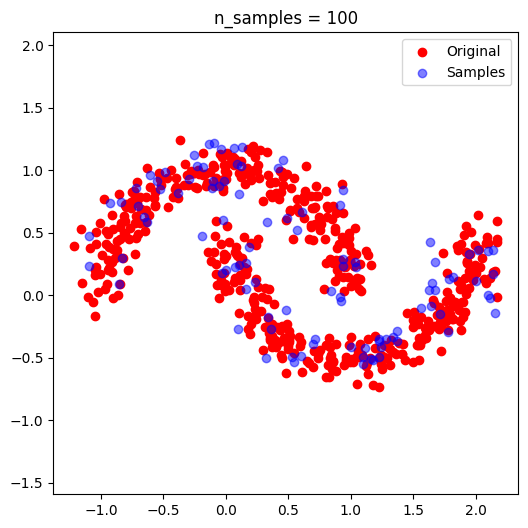

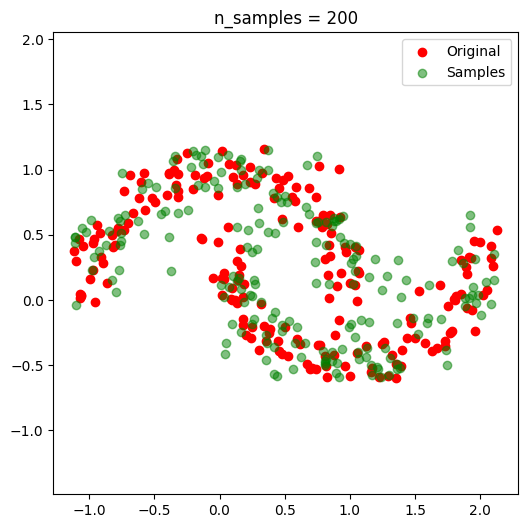

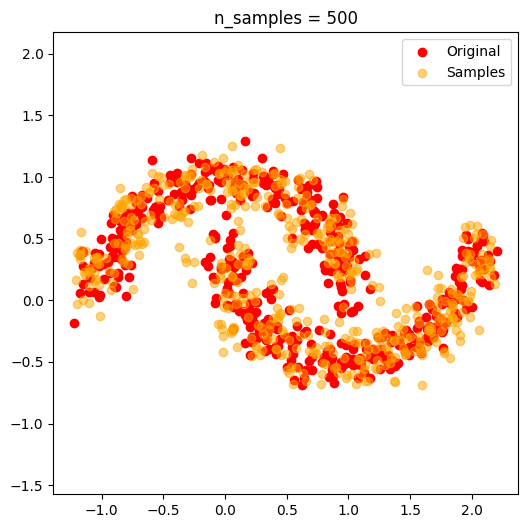

In [3]:
x1, y1 = make_moons(n_samples=500, noise=0.1, random_state=42)
x2, y2 = make_moons(n_samples=200, noise=0.1)
x5, y5 = make_moons(n_samples=500, noise=0.1)


#create the histogram objects and fit them to the data
hist1 = Histogram2D()
hist1.fit(x1)
samples1 = hist1.sample(100)  # same number of points as dataset, or whatever you choose

hist2 = Histogram2D()
hist2.fit(x2)
samples2 = hist2.sample(200)

hist5 = Histogram2D()
hist5.fit(x5)
samples5 = hist5.sample(500)


# First dataset with 100 samples
plt.figure(figsize=(6,6))
plt.scatter(x1[:,0], x1[:,1], color='red', label='Original')
plt.scatter(samples1[:,0], samples1[:,1], color='blue', alpha=0.5, label='Samples')
plt.title("n_samples = 100")
plt.axis('equal')
plt.legend()
plt.show()

# Second dataset with 200 samples
plt.figure(figsize=(6,6))
plt.scatter(x2[:,0], x2[:,1], color='red', label='Original')
plt.scatter(samples2[:,0], samples2[:,1], color='green', alpha=0.5, label='Samples')
plt.title("n_samples = 200")
plt.axis('equal')
plt.legend()
plt.show()

# Third dataset with 500 samples
plt.figure(figsize=(6,6))
plt.scatter(x5[:,0], x5[:,1], color='red', label='Original')
plt.scatter(samples5[:,0], samples5[:,1], color='orange', alpha=0.5, label='Samples')
plt.title("n_samples = 500")
plt.axis('equal')
plt.legend()
plt.show()



In [ ]:
# Kernel Density Estimation (KDE) with Gaussian Kernels
def my_bw_method():

def my_bw_method(X, grid=None, ref_covar=1e-6, weights=None, cv=5, random_state=None):
    # 
    import math
    from sklearn.model_selection import KFold

    X = np.asarray(X)
    n, d = X.shape
    if n < 2:
        return 1.0

    if grid is None:
        grid = np.logspace(-2, 1, 30)

    def logsumexp(a, axis=None):
        a_max = np.max(a, axis=axis, keepdims=True)
        s = np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True)) + a_max
        return np.squeeze(s, axis=axis)

    kf = KFold(n_splits=min(cv, n), shuffle=True, random_state=random_state)
    best_b = None
    best_score = -np.inf

    # Precompute pairwise differences per fold inside loop (can't precompute across folds)
    for b in grid:
        total_val_loglik = 0.0
        valid_b = True
        for train_idx, val_idx in kf.split(X):
            X_train = X[train_idx]
            X_val = X[val_idx]
            m_train = X_train.shape[0]
            if m_train < 1:
                valid_b = False
                break

            # sample covariance on training fold
            S = np.cov(X_train.T, bias=False) if X_train.shape[0] > 1 else np.eye(d) * 1e-8
            cov = (b ** 2) * S + ref_covar * np.eye(d)
            try:
                inv_cov = np.linalg.inv(cov)
                sign, logdet = np.linalg.slogdet(cov)
                if sign <= 0:
                    valid_b = False
                    break
            except np.linalg.LinAlgError:
                valid_b = False
                break

            # compute Mahalanobis distances between val points and train points:
            # shape (n_val, m_train)
            diff = X_val[:, None, :] - X_train[None, :, :]  # (n_val, m_train, d)
            m = np.einsum('ijk,kl,ijl->ij', diff, inv_cov, diff)  # (n_val, m_train)

            # kernel log-values
            log_k = -0.5 * m
            # log normalization constant for gaussian kernel in d dims
            log_norm = (d / 2.0) * np.log(2.0 * math.pi) + 0.5 * logdet

            # compute log pdf for each validation point: log( (1/m) sum_j exp(log_k_ij) ) - log_norm
            with np.errstate(over='ignore'):
                row_logsum = logsumexp(log_k, axis=1)  # (n_val,)
            logpdf_val = row_logsum - np.log(max(m_train, 1)) - log_norm
            total_val_loglik += np.sum(logpdf_val)

        if not valid_b:
            continue

        if total_val_loglik > best_score:
            best_score = total_val_loglik
            best_b = b

    return float(best_b if best_b is not None else 1.0)

class KDE:
    def __init__(self,
                 bandwidth=None,        # scalar or 2x2 covariance matrix; if None use bw_method
                 bw_method='scott',     # 'scott' | 'silverman' | callable(dataset) -> scalar
                 covariance_type='full',# 'full' | 'diag' | 'spherical' for bandwidth/covariance shape
                 kernel='gaussian',     # currently only 'gaussian' implemented
                 ref_covar=1e-6,        # regularizer added to covariance diagonal
                 weights=None,          # optional sample weights (shape (n_samples,))
                 random_state=None):    # seed or RandomState
        
        self.bandwidth = bandwidth
        self.bw_method = bw_method
        self.covariance_type = covariance_type
        self.kernel = kernel
        self.ref_covar = float(ref_covar)

        # weights (keep as None until fit validates length)
        self.weights = None if weights is None else np.asarray(weights, dtype=float)
        # RNG
        self.random_state = (np.random.RandomState(random_state)
                             if random_state is not None else np.random)

        # attributes set by fit()
        self.is_fitted_ = False
        self.dataset_ = None       # training data array (n_samples, 2)
        self.n_samples_ = 0
        self.n_features_ = None
        self.mean_ = None
        self.covariance_ = None    # global covariance / bandwidth matrix
        self.inv_covariance_ = None
        self.log_det_cov_ = None
        

    def fit(self, X):
        X = np.asarray(X)
        if X.ndim != 2 or X.shape[1] != 2:
            raise ValueError("X must be shape (n_samples, 2)") 
        
        #now calculate mean and covariance from data
        #def mu(X):
            

        if self.bins is None:
            bins_x = bins_1d(X[:,0])
            bins_y = bins_1d(X[:,1])
            bins = (bins_x, bins_y)
        else:
            bins = self.bins if isinstance(self.bins, tuple) else (self.bins, self.bins)
        self.bins = bins
        
        

    

IndentationError: expected an indented block after function definition on line 2 (1043511090.py, line 4)